# 02 - NYC EDA

Visualize NYC's listing market before and after Local Law 18. Build intuition before running any regressions.

In [1]:
# Data setup
# Set DATA_FILE to 'city_month_panel.parquet' after running build_real_panel.py
DATA_FILE = "city_month_panel.parquet"       # synthetic data (real not downloaded)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

panel = pd.read_parquet(DATA_DIR / DATA_FILE)
panel["month"] = pd.to_datetime(panel["month"])

regs = pd.read_csv("../data/regulations.csv", parse_dates=["enforcement_date"])

print(f"Panel: {panel.shape}  |  Cities: {sorted(panel['city'].unique())}")
print(f"Date range: {panel['month'].min().date()} to {panel['month'].max().date()}")

Panel: (288, 15)  |  Cities: ['Amsterdam', 'Barcelona', 'Florence', 'Lisbon', 'New York City', 'Vienna']
Date range: 2021-01-01 to 2024-12-01


In [2]:
nyc = panel[panel["city"] == "New York City"].copy()
nyc["post"] = nyc["month"] >= pd.Timestamp("2023-09-01")

pre_listings  = nyc[~nyc["post"]]["listings"].mean()
post_listings = nyc[nyc["post"]]["listings"].mean()
print(f"NYC mean listings — pre: {pre_listings:,.0f}  |  post: {post_listings:,.0f}")
print(f"Change: {(post_listings/pre_listings - 1)*100:+.1f}%")

NYC mean listings — pre: 22,357  |  post: 4,262
Change: -80.9%


## Figure 1 - NYC listing count over time

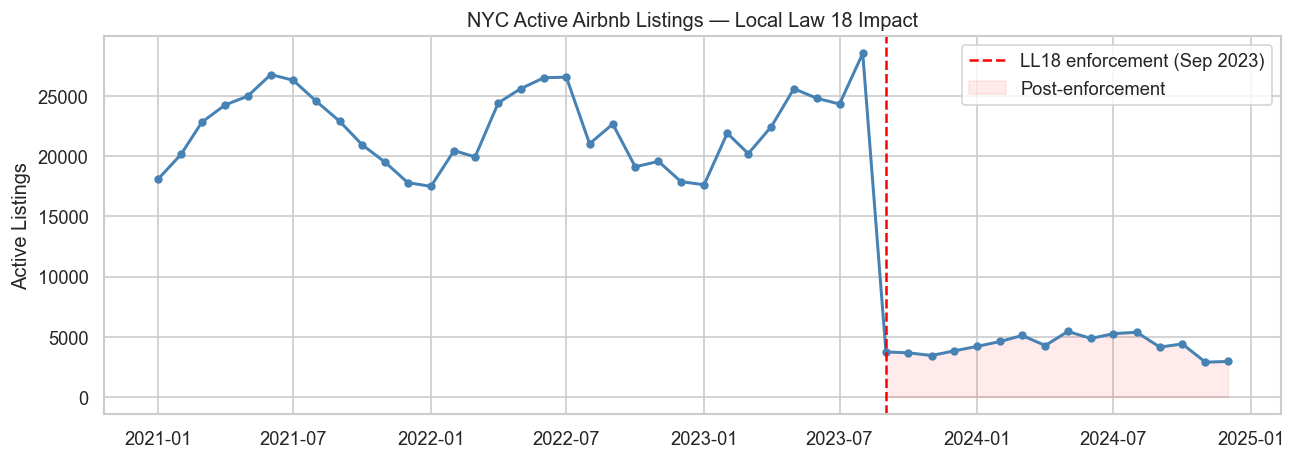

The drop is visible without any modeling. The causal question is whether it is *caused by* LL18.


In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(nyc["month"], nyc["listings"], marker="o", ms=4, lw=1.8, c="steelblue")
ax.axvline(pd.Timestamp("2023-09-01"), color="red", ls="--", lw=1.5, label="LL18 enforcement (Sep 2023)")
ax.fill_between(nyc["month"], nyc["listings"],
                where=nyc["post"], alpha=0.08, color="red", label="Post-enforcement")
ax.set_ylabel("Active Listings")
ax.set_title("NYC Active Airbnb Listings — Local Law 18 Impact")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "02_nyc_listings_raw.png", bbox_inches="tight")
plt.show()
print("The drop is visible without any modeling. The causal question is whether it is *caused by* LL18.")

## Figure 2 - All four outcomes for NYC

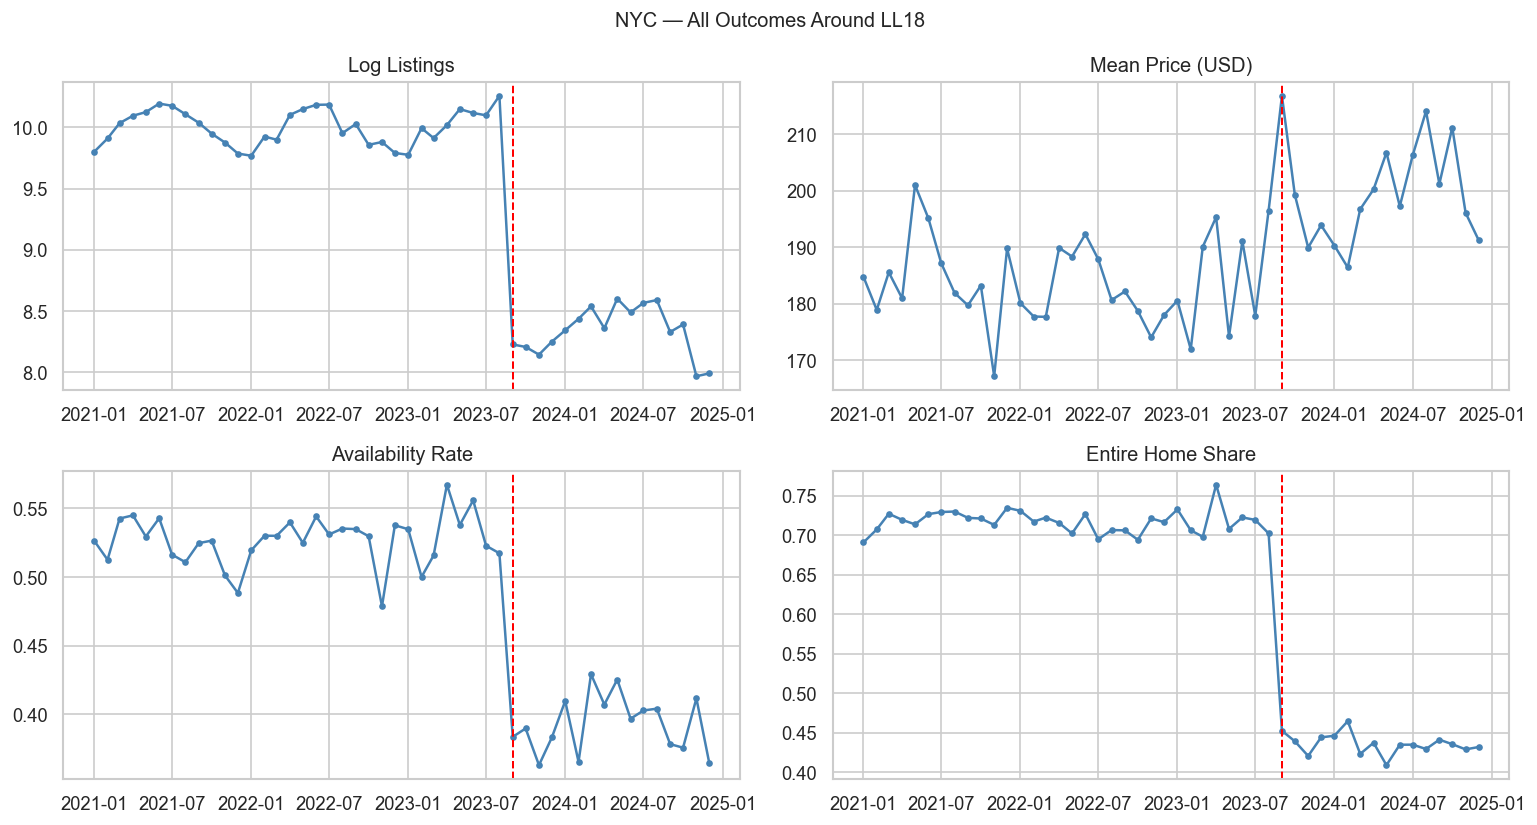

In [4]:
outcomes = ["log_listings","mean_price_usd","availability_rate","entire_home_share"]
titles   = ["Log Listings","Mean Price (USD)","Availability Rate","Entire Home Share"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, col, title in zip(axes.flat, outcomes, titles):
    ax.plot(nyc["month"], nyc[col], marker="o", ms=3, lw=1.5, c="steelblue")
    ax.axvline(pd.Timestamp("2023-09-01"), color="red", ls="--", lw=1.2)
    ax.set_title(title)
plt.suptitle("NYC — All Outcomes Around LL18", fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "02_nyc_all_outcomes.png", bbox_inches="tight")
plt.show()

## Figure 3 - NYC vs control cities (parallel trends visual)

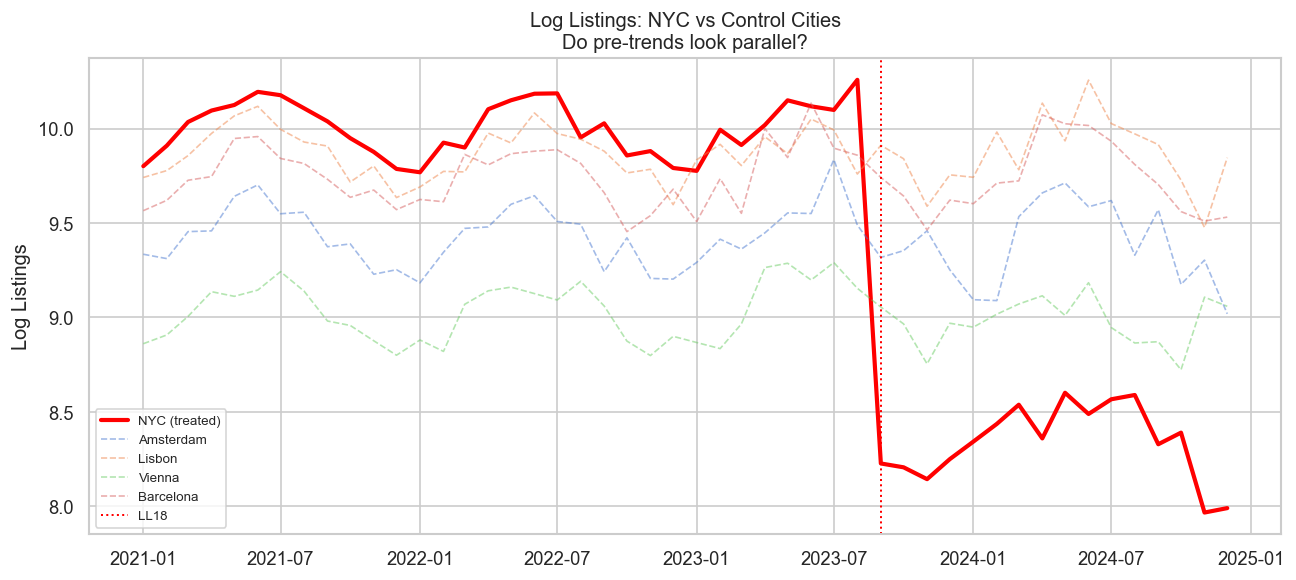

This is a visual check only — formal parallel trends test is in the event study notebook.


In [5]:
controls = ["Amsterdam","Lisbon","Vienna","Barcelona"]
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(nyc["month"], nyc["log_listings"], lw=2.5, c="red", label="NYC (treated)")
for city in controls:
    c = panel[panel["city"] == city]
    ax.plot(c["month"], c["log_listings"], lw=1.0, alpha=0.5, ls="--", label=city)
ax.axvline(pd.Timestamp("2023-09-01"), color="red", ls=":", lw=1.2, label="LL18")
ax.set_ylabel("Log Listings")
ax.set_title("Log Listings: NYC vs Control Cities\nDo pre-trends look parallel?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "02_parallel_trends_visual.png", bbox_inches="tight")
plt.show()
print("This is a visual check only — formal parallel trends test is in the event study notebook.")